<a href="https://www.kaggle.com/code/chauhanadityacse/eye-of-the-machine?scriptVersionId=268956595" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/glaucoma-detection/glaucoma.csv
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/537.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/521.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/539.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/501.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/544.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/489.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/576.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted/Validation/Glaucoma_Negative/503.jpg
/kaggle/input/glaucoma-detection/Fundus_Train_Val_

In [2]:
import os
import numpy as np
import glob
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms


# Prepare Glaucoma Dataset

In [3]:
class FullGlaucomaDataset(Dataset):
    def __init__(self, fundus_dir, origa_mat, origa_img_dir, acrima_dir, transform=None):
        self.samples = []
        self.transform = transform
        
        # 1. Fundus images
        for label_dir in ["Glaucoma_Negative", "Glaucoma_Positive"]:
            full_dir = os.path.join(fundus_dir, "Train", label_dir)
            label = 0 if "Negative" in label_dir else 1
            for f in glob.glob(full_dir + "/*.jpg"):
                self.samples.append((f,label))
        
        # 2. ORIGA
        origa_data = scipy.io.loadmat(origa_mat)['Origa']
        # ORIGA MATLAB struct -> list of dict-like items
        for i in range(len(origa_data[0])):
            fname = origa_data[0][i]['Filename'][0]
            label = int(origa_data[0][i]['Glaucoma'][0][0])
            img_path = os.path.join(origa_img_dir, fname)
            if os.path.exists(img_path):
                self.samples.append((img_path, label))
        
        # 3. ACRIMA
        for f in glob.glob(acrima_dir + "/*.jpg"):
            fname = os.path.basename(f)
            # Glaucoma label if filename has _g_
            label = 1 if "_g_" in fname else 0
            self.samples.append((f,label))
        
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label


# Train/Validatin Split

In [4]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

# 1️⃣ Transforms
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_val = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2️⃣ Paths
fundus_dir = "/kaggle/input/glaucoma-detection/Fundus_Train_Val_Data/Fundus_Scanes_Sorted"
origa_mat = "/kaggle/input/glaucoma-detection/ORIGA/ORIGA/OrigaList.mat"
origa_img_dir = "/kaggle/input/glaucoma-detection/ORIGA/ORIGA/Images"
acrima_dir = "/kaggle/input/glaucoma-detection/ACRIMA/Images"

# 3️⃣ Instantiate full dataset
full_dataset = FullGlaucomaDataset(
    fundus_dir=fundus_dir,      # <-- correct argument
    origa_mat=origa_mat,
    origa_img_dir=origa_img_dir,
    acrima_dir=acrima_dir,
    transform=transform_train
)

# 4️⃣ Train/validation split (80/20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# 5️⃣ DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print("Total samples:", len(full_dataset))
print("Train:", len(train_dataset), "Validation:", len(val_dataset))


Total samples: 1873
Train: 1498 Validation: 375


# Visualize Some Images

Training set samples:


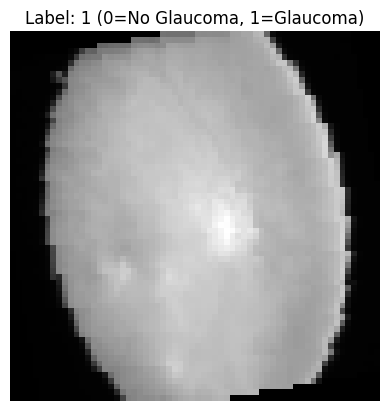

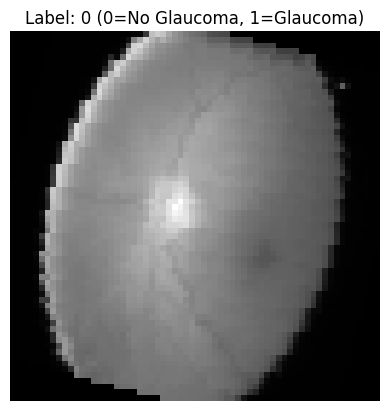

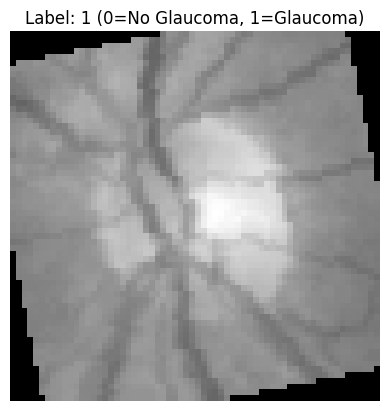

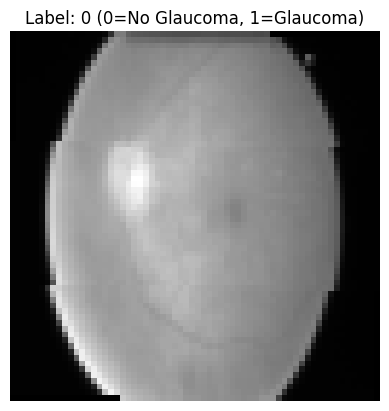

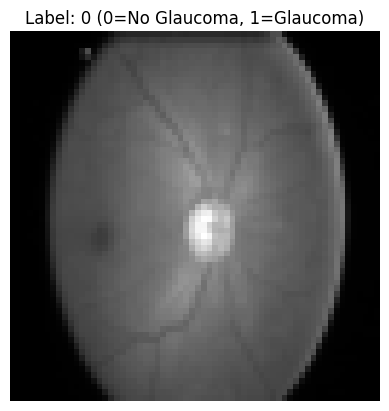

Validation set samples:


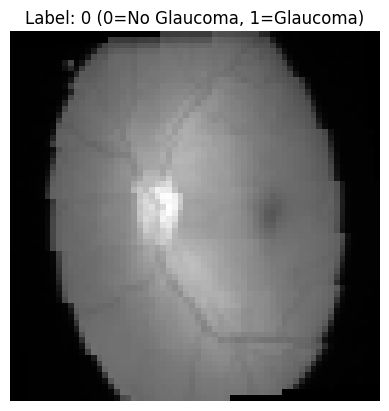

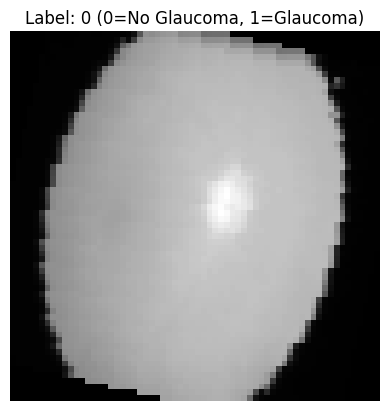

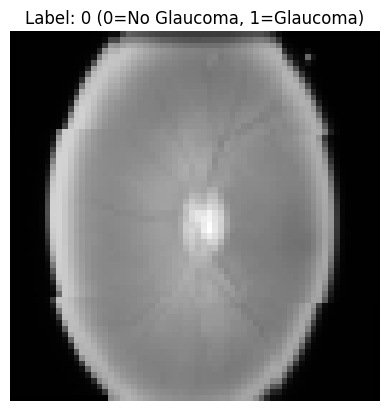

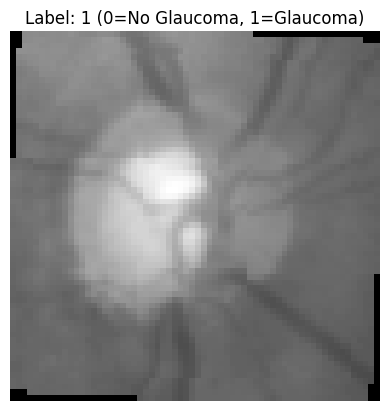

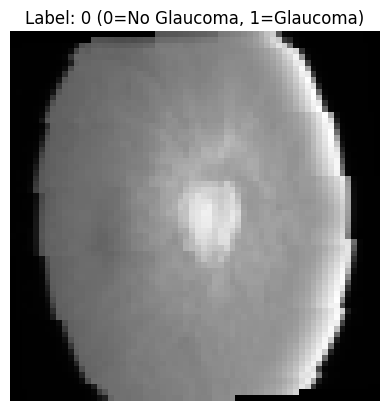

In [5]:
import matplotlib.pyplot as plt

# Function to show a few images from a DataLoader
def show_samples(loader, num_samples=5):
    images, labels = next(iter(loader))  # get one batch
    for i in range(num_samples):
        img = images[i].squeeze().cpu()  # remove channel dim and move to CPU
        label = labels[i].item()
        plt.imshow(img, cmap='gray')
        plt.title(f'Label: {label} (0=No Glaucoma, 1=Glaucoma)')
        plt.axis('off')
        plt.show()

# Show samples from training set
print("Training set samples:")
show_samples(train_loader, num_samples=5)

# Show samples from validation set
print("Validation set samples:")
show_samples(val_loader, num_samples=5)


# LeNet Model

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AdvancedLeNet(nn.Module):
    def __init__(self):
        super(AdvancedLeNet, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)  # 1x64x64 -> 16x64x64
        self.bn1 = nn.BatchNorm2d(16)
        self.pool = nn.MaxPool2d(2, 2)                            # 16x64x64 -> 16x32x32

        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2) # 16x32x32 -> 32x32x32
        self.bn2 = nn.BatchNorm2d(32)
        # pool -> 32x16x16

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32x16x16 -> 64x16x16
        self.bn3 = nn.BatchNorm2d(64)
        # pool -> 64x8x8

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 8 * 8, 256)
        self.dropout1 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, 128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(128, 2)  # 2 classes: glaucoma / non-glaucoma

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 64 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Example usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdvancedLeNet().to(device)
print(model)


AdvancedLeNet(
  (conv1): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4096, out_features=256, bias=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)


# Weighted Loss (Class Imbalance)

In [7]:
# # Compute class weights
# labels = [label for _, label in all_samples]
# class_counts = np.bincount(labels)
# class_weights = 1.0 / class_counts
# weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# criterion = nn.CrossEntropyLoss(weight=weights)
# optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training Loop

Epoch [1/20] Train Loss: 0.7212, Train Acc: 0.6162 Val Loss: 0.6045, Val Acc: 0.6933
Epoch [2/20] Train Loss: 0.6438, Train Acc: 0.6529 Val Loss: 0.6070, Val Acc: 0.7307
Epoch [3/20] Train Loss: 0.6325, Train Acc: 0.6589 Val Loss: 0.5835, Val Acc: 0.7253
Epoch [4/20] Train Loss: 0.6392, Train Acc: 0.6642 Val Loss: 0.5938, Val Acc: 0.7120
Epoch [5/20] Train Loss: 0.6166, Train Acc: 0.6789 Val Loss: 0.6017, Val Acc: 0.6747
Epoch [6/20] Train Loss: 0.6223, Train Acc: 0.6903 Val Loss: 0.6134, Val Acc: 0.6747
Epoch [7/20] Train Loss: 0.6175, Train Acc: 0.6856 Val Loss: 0.5827, Val Acc: 0.7440
Epoch [8/20] Train Loss: 0.6188, Train Acc: 0.6789 Val Loss: 0.5899, Val Acc: 0.7067
Epoch [9/20] Train Loss: 0.6081, Train Acc: 0.6916 Val Loss: 0.5975, Val Acc: 0.7547
Epoch [10/20] Train Loss: 0.6044, Train Acc: 0.6983 Val Loss: 0.5851, Val Acc: 0.7227
Epoch [11/20] Train Loss: 0.5999, Train Acc: 0.6969 Val Loss: 0.5987, Val Acc: 0.7520
Epoch [12/20] Train Loss: 0.5853, Train Acc: 0.7096 Val Loss: 0

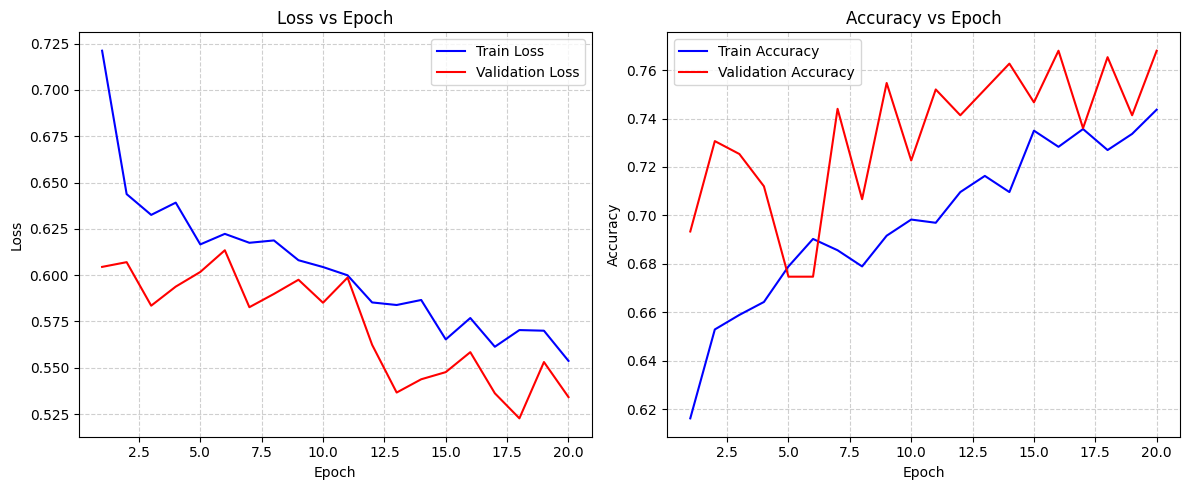

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 1️⃣ Model, criterion, optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdvancedLeNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2️⃣ Training parameters
num_epochs = 20

# Lists for tracking metrics
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

# 3️⃣ Training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# 4️⃣ Save the trained model
torch.save(model.state_dict(), "advanced_lenet_glaucoma.pth")
print("Model saved as advanced_lenet_glaucoma.pth")

# 5️⃣ Plot the metrics
plt.figure(figsize=(12,5))

# 📉 Loss
plt.subplot(1,2,1)
plt.plot(range(1, num_epochs+1), train_losses, 'b-', label='Train Loss')
plt.plot(range(1, num_epochs+1), val_losses, 'r-', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss vs Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# 📈 Accuracy
plt.subplot(1,2,2)
plt.plot(range(1, num_epochs+1), train_accuracies, 'b-', label='Train Accuracy')
plt.plot(range(1, num_epochs+1), val_accuracies, 'r-', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


# Load & Test Model

✅ Model Accuracy: 76.00%

📊 Classification Report:
              precision    recall  f1-score   support

     Healthy       0.75      0.94      0.84       243
    Glaucoma       0.80      0.42      0.55       132

    accuracy                           0.76       375
   macro avg       0.78      0.68      0.70       375
weighted avg       0.77      0.76      0.74       375



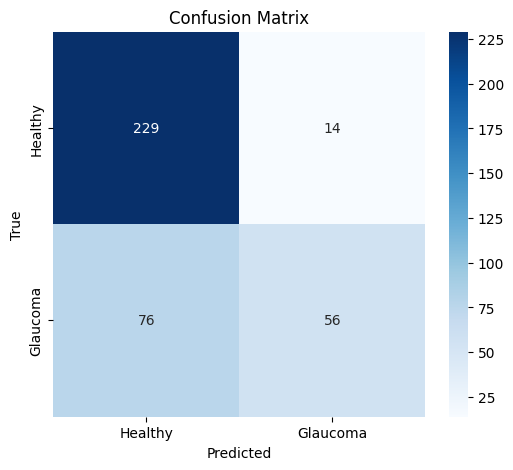

In [9]:
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Define your class names
# 👇 Replace these with your actual class labels if different
classes = ['Healthy', 'Glaucoma']

# 2️⃣ Load the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdvancedLeNet().to(device)
model.load_state_dict(torch.load("advanced_lenet_glaucoma.pth", map_location=device))
model.eval()

# 3️⃣ Evaluate on test/validation data
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:  # or test_loader if available
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 4️⃣ Accuracy
accuracy = sum([p == t for p, t in zip(all_preds, all_labels)]) / len(all_labels)
print(f"✅ Model Accuracy: {accuracy * 100:.2f}%")

# 5️⃣ Classification Report
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# 6️⃣ Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


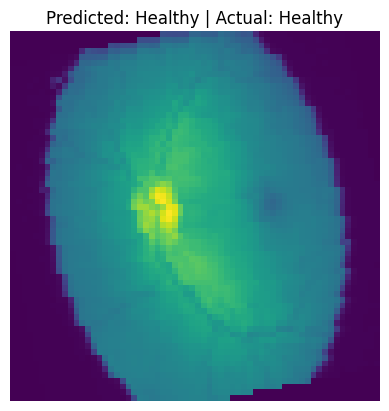

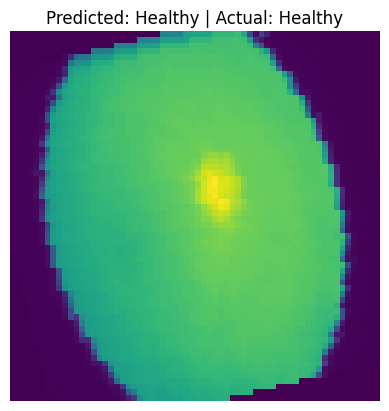

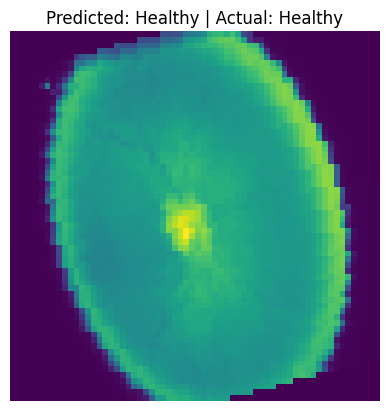

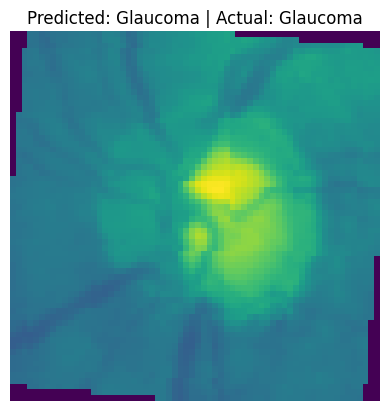

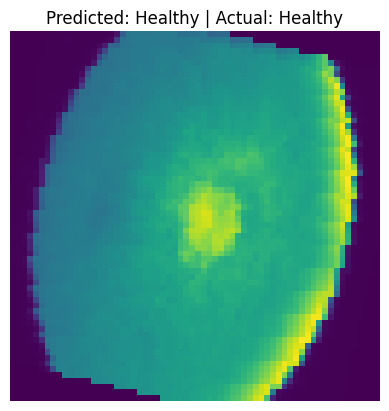


✅ Model Accuracy on this batch: 68.75%


In [10]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Define class names
classes = ['Healthy', 'Glaucoma']

# 2️⃣ Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdvancedLeNet().to(device)
model.load_state_dict(torch.load("advanced_lenet_glaucoma.pth", map_location=device))
model.eval()

# 3️⃣ Function to show image predictions
def imshow(img, title):
    img = img / 2 + 0.5  # unnormalize if you normalized [-1,1]
    npimg = img.numpy().transpose((1, 2, 0))
    plt.imshow(npimg)
    plt.axis('off')
    plt.title(title, fontsize=12)
    plt.show()

# 4️⃣ Get some random samples from validation/test loader
dataiter = iter(val_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# 5️⃣ Get predictions
outputs = model(images)
_, preds = torch.max(outputs, 1)

# 6️⃣ Display first few predictions visually
for i in range(5):  # show first 5 images
    img = images[i].cpu()
    true_label = classes[labels[i].item()]
    pred_label = classes[preds[i].item()]
    color = "green" if true_label == pred_label else "red"
    imshow(img.cpu(), title=f"Predicted: {pred_label} | Actual: {true_label}",)

# 7️⃣ Overall accuracy
correct = (preds == labels).sum().item()
total = labels.size(0)
accuracy = 100 * correct / total
print(f"\n✅ Model Accuracy on this batch: {accuracy:.2f}%")



🧠 Glaucoma-Only Accuracy: 42.42%

🔍 Sample Predictions (Glaucoma Cases):


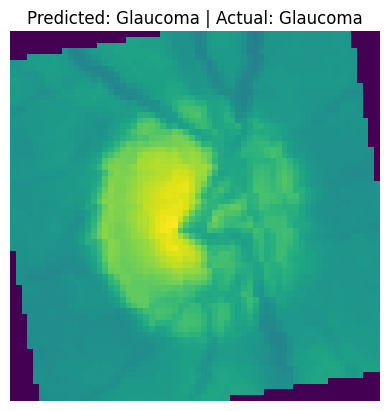

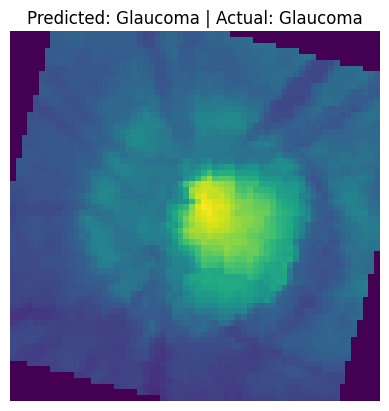

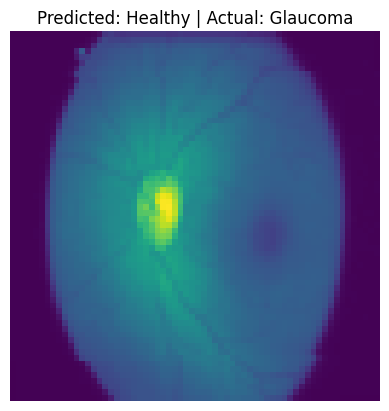

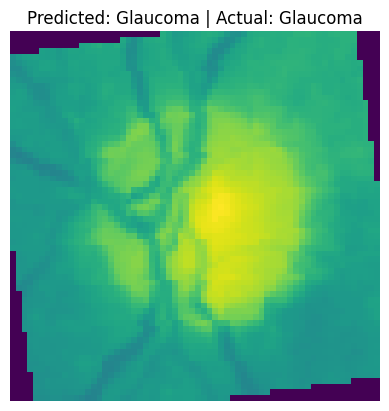

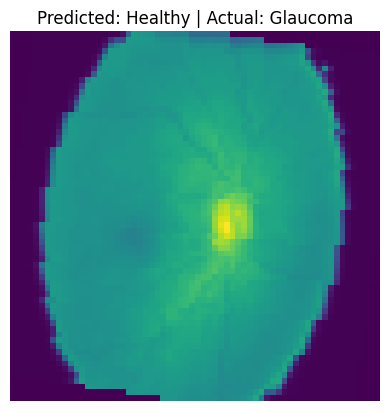

In [11]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import random

classes = ['Healthy', 'Glaucoma']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AdvancedLeNet().to(device)
model.load_state_dict(torch.load("advanced_lenet_glaucoma.pth", map_location=device))
model.eval()

def imshow(img, title):
    img = img / 2 + 0.5
    npimg = img.cpu().numpy().transpose((1, 2, 0))
    plt.imshow(npimg)
    plt.axis('off')
    plt.title(title, fontsize=12)
    plt.show()

# Collect all glaucoma samples from validation set
glaucoma_indices = [i for i, (_, label) in enumerate(val_loader.dataset) if label == 1]

correct_glaucoma = 0
total_glaucoma = len(glaucoma_indices)

# Randomly pick 5 glaucoma samples to visualize
sample_indices = random.sample(glaucoma_indices, min(5, len(glaucoma_indices)))

for idx in glaucoma_indices:  # loop over all glaucoma samples for accuracy
    image, label = val_loader.dataset[idx]
    image = image.unsqueeze(0).to(device)

    output = model(image)
    _, pred = torch.max(output, 1)

    if pred.item() == 1:
        correct_glaucoma += 1

# Glaucoma-only accuracy
glaucoma_acc = correct_glaucoma / total_glaucoma * 100
print(f"\n🧠 Glaucoma-Only Accuracy: {glaucoma_acc:.2f}%")

# Show a few random glaucoma predictions
print("\n🔍 Sample Predictions (Glaucoma Cases):")
for idx in sample_indices:
    image, label = val_loader.dataset[idx]
    image = image.unsqueeze(0).to(device)

    output = model(image)
    _, pred = torch.max(output, 1)
    pred_label = classes[pred.item()]
    true_label = classes[label]

    imshow(image.squeeze(0).cpu(), title=f"Predicted: {pred_label} | Actual: {true_label}")
